# Join `emr_cycle_outcome_processed` and `ivfs_and_transfers` and analyze combined data

A first-pass cleaning and joining of the oocyte tables before analysis.

What this notebook does, in order:
1. **Inner Join** based on patid and cycle_id
#2. **Drop** columns that are completely empty
#3. **Review** columns that hold only a single value
#4. **Merge** the oocyte dataframes (by absolute_oocyteid)
#5. **Tidy** column types
#6. **Save** a cleaned copy + keep an audit note of what changed

The same `profile()` function works on the other `emr_*` tables too, so you can reuse this pattern.

> **Before running:** finish the venv setup in this repo and install the packages — open a terminal and run `pip install pandas pyarrow`. The `requirements.txt` alongside this notebook lists everything.
>
> **Important:** keep your raw patient data in a `data/` folder that is git-ignored. Don't commit EMR exports to GitHub, even a private repo.

## Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import import_ipynb

import helper_functions

#from helper_functions import profile
#from helper_functions import drop_empty_and_constant_columns

In [2]:
# --- emr_cycle_outcome_processed ---
outcome_PATH = Path("../data/emr_cycle_outcome_processed.csv")

# loading data
outcome_df = pd.read_csv(outcome_PATH)

# --- emr_oocyte_day ---
ivf_transfer_PATH = Path("../data/ivfs_and_transfers.csv")

# loading data
ivf_transfer_df = pd.read_csv(ivf_transfer_PATH)

In [4]:
# Removing Test Accounts

# ----- outcome_df
outcome_df= helper_functions.remove_rows_by_values(outcome_df, "patid")

# ----- ivf_transfer_df
ivf_transfer_df= helper_functions.remove_rows_by_values(ivf_transfer_df, "patid")


In [5]:
#setting display options to show all columns and full width
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)        # Allow full width

## Inner Join

by patid and cycleid

In [14]:
display(
    merged_df.groupby("doctor_group")["status_x"]
    .value_counts()
    .unstack(fill_value=0)
)

status_x,Cryopreserved,Discarded,Embryo Transfer
doctor_group,,,
Kaiser,396,2,537
RPSD,736,25,984
UCSD,702,26,1106


In [18]:
# Inner join on patid and cycleid (also add in the transfer_cycles_df)

# Bringing in the transfer cycles that i know for sure are transfers
transfer_cycles_PATH = Path("../data/transfer_cycles.csv")

transfer_cycles_df = pd.read_csv(transfer_cycles_PATH)

confirmed_transfer_cycleids = set(
    transfer_cycles_df["cycleid"].dropna()
)

print(
    "Confirmed transfer cycleids:",
    len(confirmed_transfer_cycleids))


merged_df = (
    outcome_df
    .merge(
        ivf_transfer_df,
        on=["patid", "cycleid"],
        how="inner"
    )
    .merge(
        transfer_cycles_df,
        on=["patid", "cycleid"],
        how="inner"
    )
)
#display(merged_df.head(5))

Confirmed transfer cycleids: 3559


In [19]:
# connecting doctor and affiliation to merged_data
merged_df = helper_functions.add_doctor_columns(merged_df, "doctor")

In [20]:
# getting rid of the oocytes that are degraded/discarded since they were not used for transfer
# Identify oocytes that were degraded or discarded
discarded_mask = (
    merged_df["discardreason"]
        .astype(str)
        .str.contains("degraded", case=False, na=False)
    |
    merged_df["status_x"]
        .astype(str)
        .str.contains("discarded", case=False, na=False)
)

# Pull these rows aside
discarded_oocytes_df = merged_df[discarded_mask].copy()

# Get the absolute_oocyteids to remove
discarded_oocyteids = discarded_oocytes_df["absolute_oocyteid"].dropna().unique()

# Remove those oocyteids from the main dataframe
merged_df = merged_df[
    ~merged_df["absolute_oocyteid"].isin(discarded_oocyteids)
].copy()

print("Discarded/degraded rows:", len(discarded_oocytes_df))
print("Oocyte IDs removed:", len(discarded_oocyteids))
print("Merged DF shape after removal:", merged_df.shape)


Discarded/degraded rows: 53
Oocyte IDs removed: 41
Merged DF shape after removal: (6257, 81)


In [21]:
# getting rid of blastocysts without a grade (sometimes weird transfers - ex: a 9cell was transferred to patient 11326)

merged_df["latest_grade"].isna().sum() # count how many (101 - many of them likely duplicates)

merged_df = merged_df.dropna(subset=["latest_grade"])

In [22]:
#  If duplicates exist for cycleid + absolute_oocyteid, fill missing values based on other rows
cols_to_fill = [
    "cryopreserved",
    "treatment_performed",
    "ord",
    "grade",
    "pgd_result",
    "pgd_note",
    "status_x"
]

merged_df[cols_to_fill] = (
    merged_df
    .groupby(["cycleid", "absolute_oocyteid"])[cols_to_fill]
    .transform(lambda x: x.ffill().bfill())
)

# this assumes that within a given cycleid + absolute_oocyteid, the non-NA values are consistent 
# if one duplicate says grade = "AAG" and another says grade = "ABG", this approach will choose 
# based on row order.

# see how many rows are removed after dropping duplicates
before = len(merged_df)

merged_df = merged_df.drop_duplicates()

after = len(merged_df)

print("Shape before:", (before, merged_df.shape[1]))
print("Shape after:", merged_df.shape)
print("Rows removed:", before - after)


Shape before: (6185, 81)
Shape after: (5945, 81)
Rows removed: 240


In [23]:
# looking at and solving abnormalities:
#merged_df = merged_df[
#    ~(
#        ((merged_df["cycleid"] == "06213698-ad83-49c4-82f3-752af0e6ea65") & (merged_df["absolute_oocyteid"] == "6edc27a9-1f8c-4193-96ef-a02cc2135625"))| # no reason for 2 oocyteids since there was only one transferred
#        ((merged_df["cycleid"] == "af5ac320-1d41-48eb-810a-7cfb94860048") & (merged_df["absolute_oocyteid"] == "7435764d-e869-473f-8138-41a7ab1c3574"))| # no reason for 2 oocyteids since there was only one transferred
#        ((merged_df["cycleid"] == "674885f0-d669-4a64-a948-ccbdf1753f16") & (merged_df["absolute_oocyteid"] == "4f3a1cc0-3c1e-4994-a2b9-8bd3abb147f4"))|
#        ((merged_df["cycleid"] == "497d15ff-ce09-4414-a1f4-e2d1cfd9ee57") & (merged_df["absolute_oocyteid"] == "7435764d-e869-473f-8138-41a7ab1c3574")) # no reason for 2 oocyteids since there was only one transferred # no reason for 2 oocyteids since there was only one transferred
#    )
#]

#______________________________________________________
# for cases where there are more than 5 rows for a cycleid, then keep the row that says "Embryo Transfer"
cycle_counts = merged_df.groupby("cycleid")["cycleid"].transform("size")

merged_df = merged_df[
    (cycle_counts <= 5) |
    (merged_df["status_x"] == "Embryo Transfer")
].copy() # this is especially for older cases and maybe retrievals that were done in ARTWORKS but then transfer done in nAble

#______________________________________________________
# for cases of multiple oocyteids being associated with a cycle, only keep the case where the treatment_performed is not NA
multiple_oocyte_cycles = (
    merged_df.groupby("cycleid")["absolute_oocyteid"]
    .transform("nunique") > 1
)

merged_df = merged_df[
    ~multiple_oocyte_cycles | merged_df["treatment_performed"].notna()
].copy() # this seems to be the pattern for these cases

#______________________________________________________
# for cases of multiple oocyteids associated with a cycle, get rid of rows where cryopreserved has a date and the date is after "treatment_performed"
# Then keep row with absolute_oocyteid that has no value for cryopreserved and status_x = "Embryo Transfer"
# This seems to be the pattern to use in cases of Oocyte Thaw + Fresh Transfer
# Make sure dates are datetime
merged_df["cryopreserved"] = pd.to_datetime(
    merged_df["cryopreserved"], errors="coerce"
)
merged_df["treatment_performed"] = pd.to_datetime(
    merged_df["treatment_performed"], errors="coerce"
)

# Identify cycles with multiple absolute_oocyteids
multi_oocyte = (
    merged_df.groupby("cycleid")["absolute_oocyteid"]
    .transform("nunique") > 1
)

# Identify rows where cryopreserved occurred after treatment_performed
cryopreserved_after_transfer = (
    merged_df["cryopreserved"].notna()
    & merged_df["treatment_performed"].notna()
    & (merged_df["cryopreserved"] > merged_df["treatment_performed"])
)

# Get the cycleids affected by this situation
affected_cycles = merged_df.loc[
    multi_oocyte & cryopreserved_after_transfer,
    "cycleid"
].unique()

# For affected cycles, keep only:
# cryopreserved = NA AND status_x = Embryo Transfer
keep = ~merged_df["cycleid"].isin(affected_cycles) | (
    merged_df["cryopreserved"].isna()
    & merged_df["status_x"].eq("Embryo Transfer")
)

merged_df = merged_df[keep].copy()

#______________________________________________________




In [24]:
merged_df.shape

(4243, 81)

In [ ]:
# getting df of cases with more than 1 absolute_oocyteid associated with a cycleid
multi_oocyte_cycles = merged_df[
    merged_df.groupby("cycleid")["absolute_oocyteid"]
    .transform("nunique") > 1
].copy() # for now assuming that these cases are cases where 2 embryos are transferred, which makes it difficult to disect which embryo ended up in the pregnancy/miscarriage/etc.

display(multi_oocyte_cycles.head(20))

print(multi_oocyte_cycles.shape)


,patid,cycleid,cycle_outcome,max_fetal_hearts,max_fetal_hearts_2,num_fetus,complication,note,preg_outcome,aspirationid,treatment,treatment_performed,cryopreserved,ord,max_day,absolute_oocyteid,day,stage,grade,discardreason,oocyte_grade,pgd_result,pgd_note,status_x,granular,vacuoles,fragments,inclusions,cldga,degenerating,ser,refractile_body,dark,retracted,no_resistance,sticky_or_difficult,large_pvs,dark_pvs,fragmented_pb,multiple_pb,abnormal_pb_size,ghost_pb,detached_pb,pvs_debris,possible_parth,pb_je,latest_grade,n_eggs_retrieval,n_unfertilized,day_blastocyst,2_pn,grade_nonspecific,blastocyst_stage,complex_aneuploid,low_mosaic,high_mosaic,chaotic,euploid,aneuploid,partnerid,sart_id,status_y,closed,cycletype,cycle_name,cyclestart,cycleend,event_labels,plan_treatment,hist_monthsattempting,main_note,height,weight,bmi,hist_smoker,hist_pat_surg_sterile,doctor,doctor_id,doctor_key,name,doctor_group
648,26673,383b1f86-4e79-4762-9838-c1c50b9f8c86,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,1813089b-d61f-42b7-950f-032d326bdb0c,ICSI,2022-06-01,NaT,5.0,5.0,a3c4b839-4e44-47d0-8f5e-ca19ef896528,5,hatchingblast,BCF-P,NaN,NaN,high level mosaic,High Level Mosaic: -5[mos] XX,Cryopreserved,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BCF-P,5.0,0,5.0,1,F-P,4.0,0,0,1,0,0,0,26674.0,n_7868,Completed,True,3e0aacef-70d9-40d3-81a9-b2d0494a8c20,FET: FET: Transdermal Patches,5/17/2022,6/14/2022,1=LMP,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,4.0,FET\nLabs complete\nPost-thaw assessment: VT@1...,177.80,99.155410,31.37,-98.0,-1.0,1,1,1,Dr. Vicente Garzo Toro,RPSD
649,26673,383b1f86-4e79-4762-9838-c1c50b9f8c86,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,1813089b-d61f-42b7-950f-032d326bdb0c,ICSI,2022-06-01,NaT,5.0,5.0,a3c4b839-4e44-47d0-8f5e-ca19ef896528,5,hatchingblast,BCF-P,NaN,NaN,high level mosaic,High Level Mosaic: -5[mos] XX,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BCF-P,5.0,0,5.0,1,F-P,4.0,0,0,1,0,0,0,26674.0,n_7868,Completed,True,3e0aacef-70d9-40d3-81a9-b2d0494a8c20,FET: FET: Transdermal Patches,5/17/2022,6/14/2022,1=LMP,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,4.0,FET\nLabs complete\nPost-thaw assessment: VT@1...,177.80,99.155410,31.37,-98.0,-1.0,1,1,1,Dr. Vicente Garzo Toro,RPSD
650,26673,383b1f86-4e79-4762-9838-c1c50b9f8c86,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,1813089b-d61f-42b7-950f-032d326bdb0c,ICSI,2022-06-02,NaT,3.0,6.0,911f4542-bf4a-4e5f-a40b-61d75f7b0d25,6,hatchingblast,BBF,NaN,NaN,euploid,NaN,Cryopreserved,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BBF,5.0,0,6.0,1,F,4.0,0,0,0,0,1,0,26674.0,n_7868,Completed,True,3e0aacef-70d9-40d3-81a9-b2d0494a8c20,FET: FET: Transdermal Patches,5/17/2022,6/14/2022,1=LMP,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,4.0,FET\nLabs complete\nPost-thaw assessment: VT@1...,177.80,99.155410,31.37,-98.0,-1.0,1,1,1,Dr. Vicente Garzo Toro,RPSD
651,26673,383b1f86-4e79-4762-9838-c1c50b9f8c86,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,1813089b-d61f-42b7-950f-032d326bdb0c,ICSI,2022-06-02,NaT,3.0,6.0,911f4542-bf4a-4e5f-a40b-61d75f7b0d25,6,hatchingblast,BBF,NaN,NaN,euploid,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BBF,5.0,0,6.0,1,F,4.0,0,0,0,0,1,0,26674.0,n_7868,Completed,True,3e0aacef-70d9-40d3-81a9-b2d0494a8c20,FET: FET: Transdermal Patches,5/17/2022,6/14/2022,1=LMP,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,4.0,FET\nLabs complete\nPost-thaw assessment: VT@1...,177.80,99.155410,31.37,-98.0,-1.0,1,1,1,Dr. Vicente Garzo Toro,RPSD
876,15536,7dcb3676-48d2-42eb-8238-44f501a68c10,Clinical Intrauterine Gestation,1.0,1.0,1.0,NaN,NaN,Live birth,NaN,NaN,2022-05-13,2018-05-17,20.0,5.0,999f6acd-1af6-42bf-bdfb-4aeb49356bb1,5,earlyblast,BCP,NaN,NaN,normal,Igenomix,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BCP,20.0,0,5.0,1,P,1.0,0,0,0,0,0,0,15537.0,n_2644,Completed,True,7bb2f39f-bb02-4a72-8c82-4fb9538fe83a,FET: FET: Natural,4/26/2022,1/26/2023,1=LMP&19=FET,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,42.0,NAT FET - CD1 04/26/22\nPt to have US day afte...,165.10,61.688636,22.63,0.0,-1.0,6,6,6,Dr. Sanjay Agarwal,UCSD
880,15536,7

(94, 81)


In [26]:
# getting rid of the multi_oocyte_cycles cases
merged_df = merged_df[
    ~merged_df["cycleid"].isin(multi_oocyte_cycles["cycleid"])
].copy()

In [27]:
display(merged_df.shape)

(4149, 81)

In [38]:
# Getting rid of duplicate rows (make sure grade is filled out and most of the time it is between a cryopreservation row and a transfer row)
# Flag rows so preferred ones sort to the top
merged_df['_has_grade']   = merged_df['grade'].notna() & (merged_df['grade'].astype(str).str.strip() != '')
merged_df['_is_transfer'] = merged_df['status_x'] == 'Embryo Transfer'

before = len(merged_df)

merged_df = (
    merged_df
    .sort_values(['_has_grade', '_is_transfer'], ascending=[False, False])
    .drop_duplicates(subset=['absolute_oocyteid', 'cycleid'], keep='first')
    .drop(columns=['_has_grade', '_is_transfer'])
    .sort_index()
    .reset_index(drop=True)
)

print(f"Rows before dedup: {before}")
print(f"Rows after dedup:  {len(merged_df)}")
print(f"Removed:           {before - len(merged_df)}")

# Sanity check: every (absolute_oocyteid, cycleid) should now be unique
assert not merged_df.duplicated(subset=['absolute_oocyteid', 'cycleid']).any()


Rows before dedup: 4149
Rows after dedup:  2468
Removed:           1681


In [39]:
# Check for cycleids appearing on more than one row
cycle_counts = merged_df['cycleid'].value_counts()
multi_row_cycles = cycle_counts[cycle_counts > 1]

print(f"Total unique cycleids:            {len(cycle_counts)}")
print(f"Cycleids with >1 row:             {len(multi_row_cycles)}")
print(f"Cycleids with exactly 1 row:      {(cycle_counts == 1).sum()}")

if len(multi_row_cycles) > 0:
    print(f"\nRow count distribution for multi-row cycleids:")
    print(multi_row_cycles.value_counts().sort_index())
    print(f"\nTop 10 cycleids with the most rows:")
    print(multi_row_cycles.head(10))

Total unique cycleids:            2468
Cycleids with >1 row:             0
Cycleids with exactly 1 row:      2468


In [28]:
display(merged_df.columns)

Index(['patid', 'cycleid', 'cycle_outcome', 'max_fetal_hearts',
       'max_fetal_hearts_2', 'num_fetus', 'complication', 'note',
       'preg_outcome', 'aspirationid', 'treatment', 'treatment_performed',
       'cryopreserved', 'ord', 'max_day', 'absolute_oocyteid', 'day', 'stage',
       'grade', 'discardreason', 'oocyte_grade', 'pgd_result', 'pgd_note',
       'status_x', 'granular', 'vacuoles', 'fragments', 'inclusions', 'cldga',
       'degenerating', 'ser', 'refractile_body', 'dark', 'retracted',
       'no_resistance', 'sticky_or_difficult', 'large_pvs', 'dark_pvs',
       'fragmented_pb', 'multiple_pb', 'abnormal_pb_size', 'ghost_pb',
       'detached_pb', 'pvs_debris', 'possible_parth', 'pb_je', 'latest_grade',
       'n_eggs_retrieval', 'n_unfertilized', 'day_blastocyst', '2_pn',
       'grade_nonspecific', 'blastocyst_stage', 'complex_aneuploid',
       'low_mosaic', 'high_mosaic', 'chaotic', 'euploid', 'aneuploid',
       'partnerid', 'sart_id', 'status_y', 'closed', 'cycle

## 4. Plots of cycle outcomes

based on grade and ploidy status

In [40]:
display(merged_df["cycle_outcome"].value_counts())

cycle_outcome
Clinical Intrauterine Gestation    1294
Not Pregnant                        632
Biochemical                         233
Unknown                              45
Ectopic                              33
Name: count, dtype: int64

In [41]:
display(
    merged_df.groupby("doctor_group")["cycle_outcome"]
    .value_counts()
    .unstack(fill_value=0)
)

cycle_outcome,Biochemical,Clinical Intrauterine Gestation,Ectopic,Not Pregnant,Unknown
doctor_group,,,,,
Kaiser,46,268,4,125,44
RPSD,81,486,11,234,1
UCSD,106,540,18,273,0


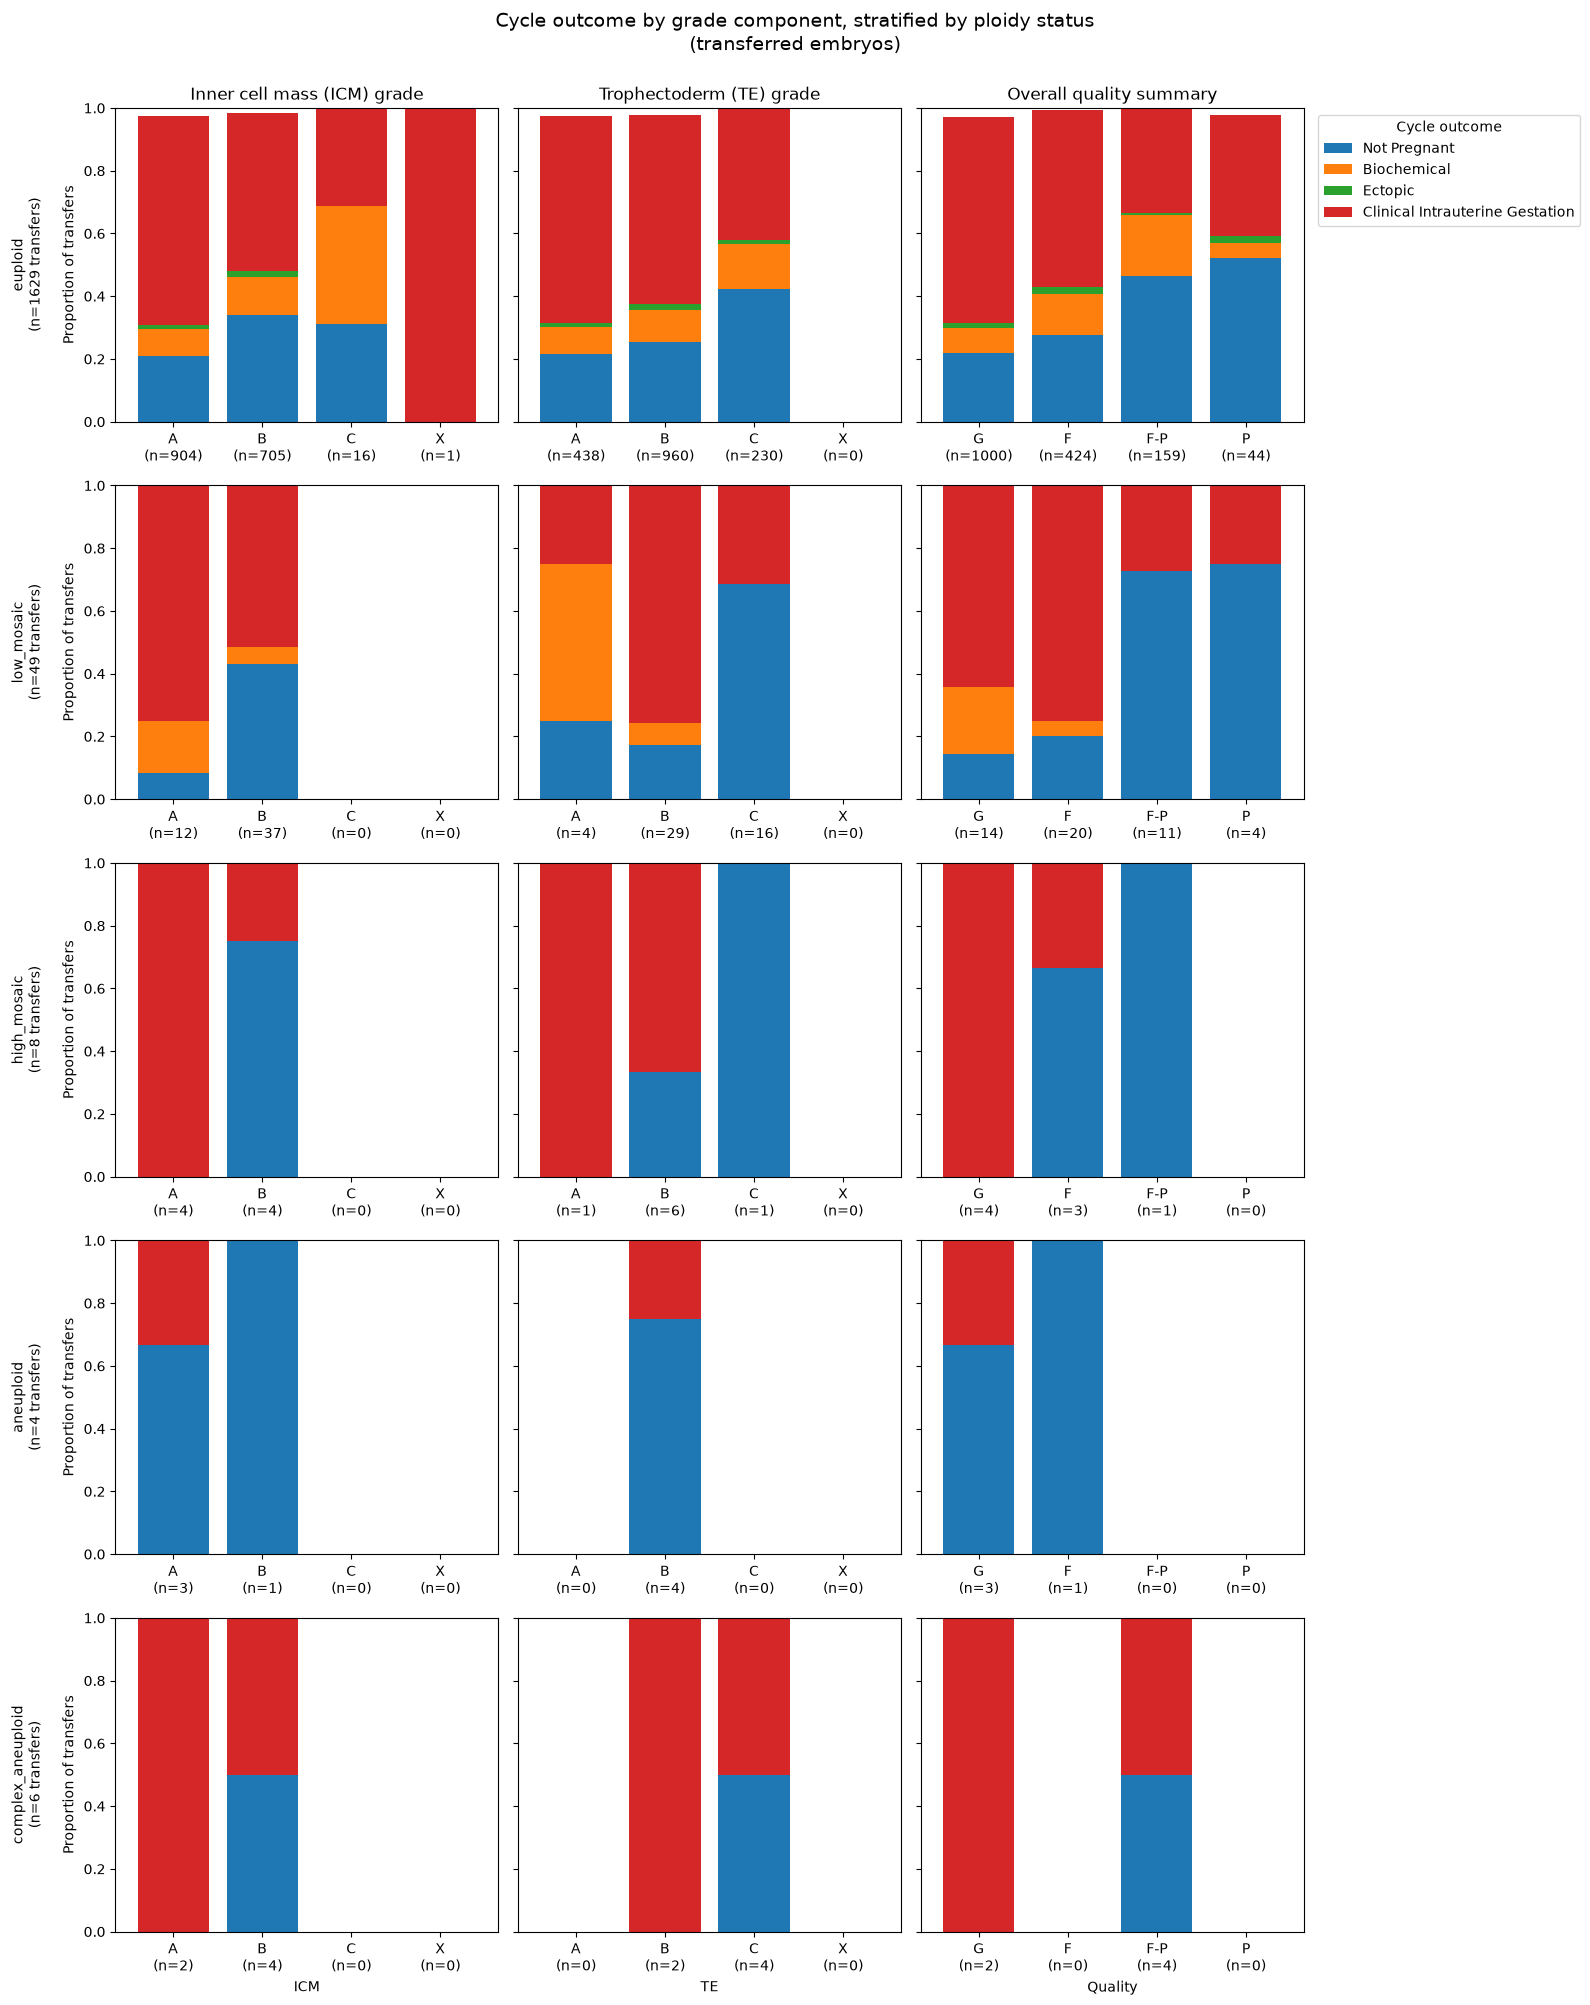

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Prep ---
transferred = merged_df.copy()

# Grade components
transferred['icm']     = transferred['grade'].str[0]                              # A / B / C / X
transferred['te']      = transferred['grade'].str[1]                              # A / B / C / X
transferred['quality'] = transferred['grade'].str.extract(r'(G|F-P|F|P)$')

# Build ploidy_outcome from the binary columns (pick whichever is 1)
ploidy_cols = ['euploid', 'low_mosaic', 'high_mosaic', 'aneuploid', 'complex_aneuploid']
def pick_ploidy(row):
    for c in ploidy_cols:
        if row.get(c) == 1:
            return c
    return None
transferred['ploidy_outcome'] = transferred.apply(pick_ploidy, axis=1)

# Only keep rows with a cycle_outcome and a ploidy status
transferred = transferred[transferred['cycle_outcome'].notna() &
                          transferred['ploidy_outcome'].notna()]

# --- Ordered categories ---
icm_order     = ['A', 'B', 'C', 'X']
te_order      = ['A', 'B', 'C', 'X']
quality_order = ['G', 'F', 'F-P', 'P']

ploidy_order = ['euploid', 'low_mosaic', 'high_mosaic', 'aneuploid', 'complex_aneuploid']
ploidy_present = [p for p in ploidy_order if (transferred['ploidy_outcome'] == p).any()]

# Cycle outcome stacking order (worst -> best, so best sits on top)
outcome_order = ['Not Pregnant', 'Biochemical', 'Ectopic', 'Clinical Intrauterine Gestation']
outcome_order = [o for o in outcome_order if o in transferred['cycle_outcome'].unique()]

def build_tables(sub, col, order):
    props  = pd.crosstab(sub[col], sub['cycle_outcome'], normalize='index').reindex(order)
    counts = pd.crosstab(sub[col], sub['cycle_outcome']).reindex(order)
    props  = props.reindex(columns=outcome_order, fill_value=0)
    return props, counts.sum(axis=1).fillna(0)

# --- Plot: rows = ploidy status, cols = ICM / TE / Quality ---
n_rows = len(ploidy_present)
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4 * n_rows), sharey=True, squeeze=False)

col_specs = [
    ('icm',     icm_order,     "Inner cell mass (ICM) grade", "ICM"),
    ('te',      te_order,      "Trophectoderm (TE) grade",    "TE"),
    ('quality', quality_order, "Overall quality summary",     "Quality"),
]

for row_idx, ploidy in enumerate(ploidy_present):
    sub = transferred[transferred['ploidy_outcome'] == ploidy]
    n_ploidy = len(sub)
    for col_idx, (col, order, title, xlabel) in enumerate(col_specs):
        ax = axes[row_idx, col_idx]
        props, n = build_tables(sub, col, order)

        props.plot(kind='bar', stacked=True, ax=ax, width=0.8, legend=False)
        ax.set_xticklabels(
            [f"{g}\n(n={int(n.loc[g])})" for g in order],
            rotation=0,
        )
        ax.set_ylim(0, 1)
        ax.set_xlabel(xlabel if row_idx == n_rows - 1 else "")

        if row_idx == 0:
            ax.set_title(title)

        if col_idx == 0:
            ax.set_ylabel(f"{ploidy}\n(n={n_ploidy} transfers)\n\nProportion of transfers")
        else:
            ax.set_ylabel("")

axes[0, -1].legend(title="Cycle outcome", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.suptitle("Cycle outcome by grade component, stratified by ploidy status\n(transferred embryos)",
             y=1.00, fontsize=14)
plt.tight_layout()
plt.show()

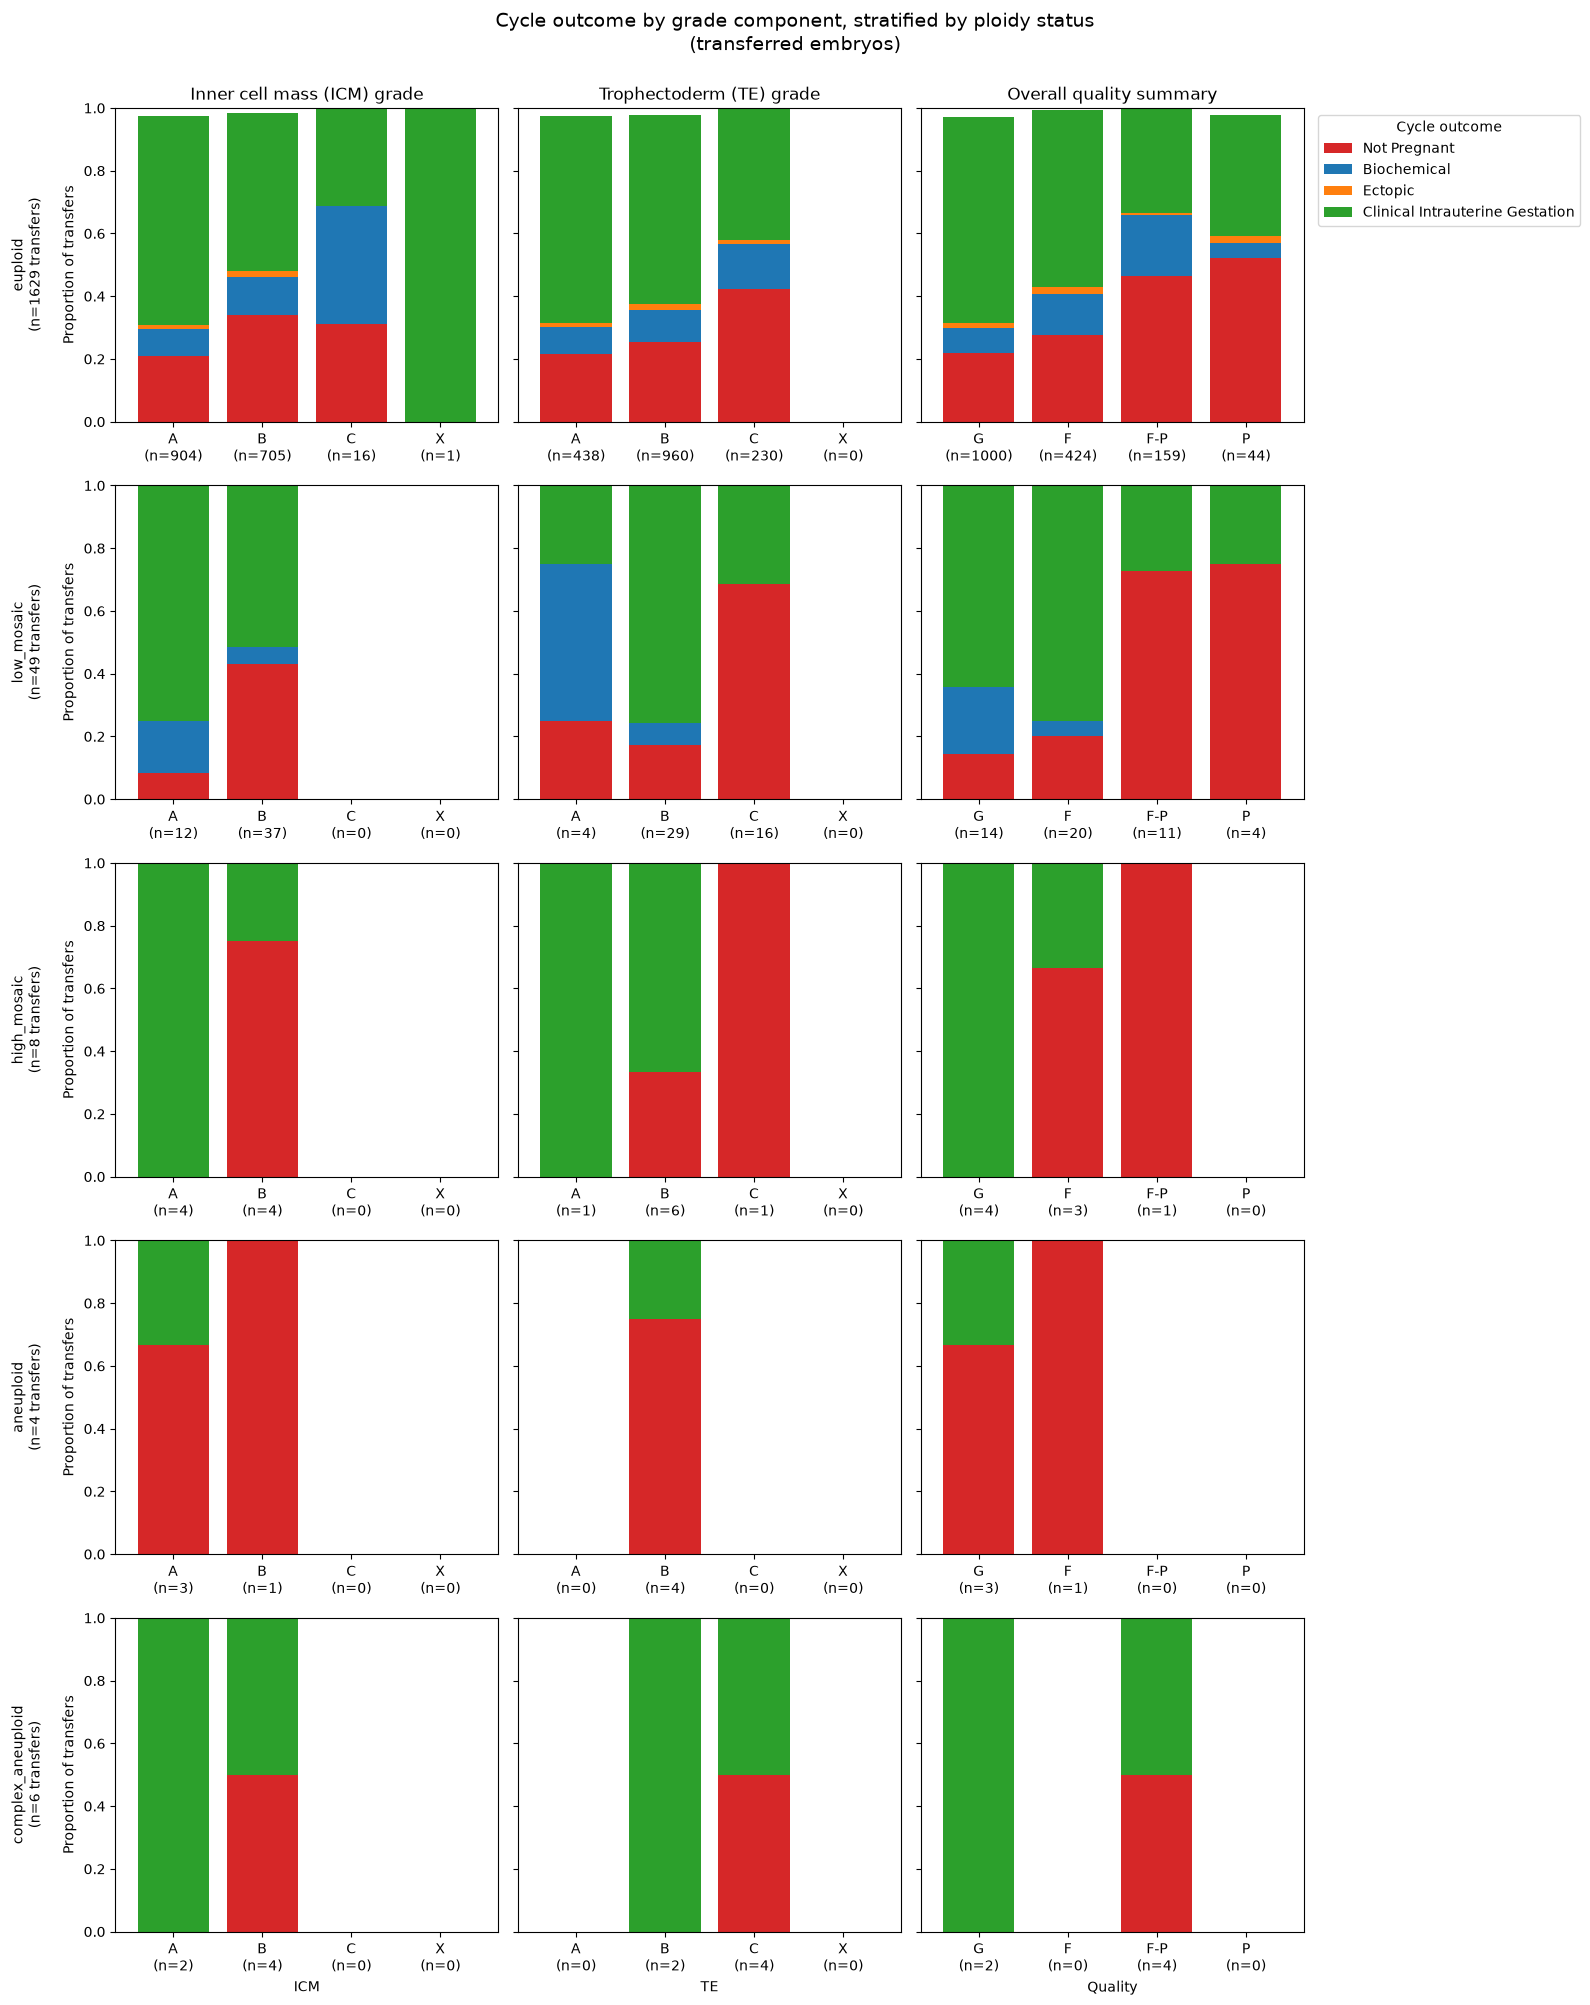

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Prep ---
transferred = merged_df.copy()

# Grade components
transferred['icm']     = transferred['grade'].str[0]                              # A / B / C / X
transferred['te']      = transferred['grade'].str[1]                              # A / B / C / X
transferred['quality'] = transferred['grade'].str.extract(r'(G|F-P|F|P)$')

# Build ploidy_outcome from the binary columns (pick whichever is 1)
ploidy_cols = ['euploid', 'low_mosaic', 'high_mosaic', 'aneuploid', 'complex_aneuploid']
def pick_ploidy(row):
    for c in ploidy_cols:
        if row.get(c) == 1:
            return c
    return None
transferred['ploidy_outcome'] = transferred.apply(pick_ploidy, axis=1)

# Only keep rows with a cycle_outcome and a ploidy status
transferred = transferred[transferred['cycle_outcome'].notna() &
                          transferred['ploidy_outcome'].notna()]

# --- Ordered categories ---
icm_order     = ['A', 'B', 'C', 'X']
te_order      = ['A', 'B', 'C', 'X']
quality_order = ['G', 'F', 'F-P', 'P']

ploidy_order = ['euploid', 'low_mosaic', 'high_mosaic', 'aneuploid', 'complex_aneuploid', 'chaotic']
ploidy_present = [p for p in ploidy_order if (transferred['ploidy_outcome'] == p).any()]

# Cycle outcome stacking order (worst -> best, so best sits on top)
outcome_order = ['Not Pregnant', 'Biochemical', 'Ectopic', 'Clinical Intrauterine Gestation']
outcome_order = [o for o in outcome_order if o in transferred['cycle_outcome'].unique()]

# Explicit color mapping
outcome_colors = {
    'Not Pregnant':                    '#d62728',   # red
    'Biochemical':                     '#1f77b4',   # blue
    'Ectopic':                         '#ff7f0e',   # orange
    'Clinical Intrauterine Gestation': '#2ca02c',   # green
}
bar_colors = [outcome_colors[o] for o in outcome_order]

def build_tables(sub, col, order):
    props  = pd.crosstab(sub[col], sub['cycle_outcome'], normalize='index').reindex(order)
    counts = pd.crosstab(sub[col], sub['cycle_outcome']).reindex(order)
    props  = props.reindex(columns=outcome_order, fill_value=0)
    return props, counts.sum(axis=1).fillna(0)

# --- Plot: rows = ploidy status, cols = ICM / TE / Quality ---
n_rows = len(ploidy_present)
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4 * n_rows), sharey=True, squeeze=False)

col_specs = [
    ('icm',     icm_order,     "Inner cell mass (ICM) grade", "ICM"),
    ('te',      te_order,      "Trophectoderm (TE) grade",    "TE"),
    ('quality', quality_order, "Overall quality summary",     "Quality"),
]

for row_idx, ploidy in enumerate(ploidy_present):
    sub = transferred[transferred['ploidy_outcome'] == ploidy]
    n_ploidy = len(sub)
    for col_idx, (col, order, title, xlabel) in enumerate(col_specs):
        ax = axes[row_idx, col_idx]
        props, n = build_tables(sub, col, order)

        props.plot(kind='bar', stacked=True, ax=ax, width=0.8, legend=False,
                   color=bar_colors)
        ax.set_xticklabels(
            [f"{g}\n(n={int(n.loc[g])})" for g in order],
            rotation=0,
        )
        ax.set_ylim(0, 1)
        ax.set_xlabel(xlabel if row_idx == n_rows - 1 else "")

        if row_idx == 0:
            ax.set_title(title)

        if col_idx == 0:
            ax.set_ylabel(f"{ploidy}\n(n={n_ploidy} transfers)\n\nProportion of transfers")
        else:
            ax.set_ylabel("")

axes[0, -1].legend(title="Cycle outcome", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.suptitle("Cycle outcome by grade component, stratified by ploidy status\n(transferred embryos)",
             y=1.00, fontsize=14)
plt.tight_layout()
plt.show()

In [44]:
# Isolate transfers where an aneuploid or complex aneuploid embryo was transferred
aneuploid_transfers = merged_df[
    (merged_df['cycle_outcome'].notna()) &
    ((merged_df['aneuploid'] == 1) | (merged_df['complex_aneuploid'] == 1))
].copy()

print(f"Total aneuploid/complex aneuploid transfers: {len(aneuploid_transfers)}")
print(f"Unique cycles: {aneuploid_transfers['cycleid'].nunique()}")
print(f"Unique patients: {aneuploid_transfers['patid'].nunique()}")
print("\nBreakdown:")
print(aneuploid_transfers[['aneuploid', 'complex_aneuploid']].sum())
print("\nCycle outcomes:")
print(aneuploid_transfers['cycle_outcome'].value_counts())

Total aneuploid/complex aneuploid transfers: 10
Unique cycles: 10
Unique patients: 10

Breakdown:
aneuploid            4
complex_aneuploid    6
dtype: int64

Cycle outcomes:
cycle_outcome
Not Pregnant                       5
Clinical Intrauterine Gestation    5
Name: count, dtype: int64


In [45]:
display(aneuploid_transfers)

,patid,cycleid,cycle_outcome,max_fetal_hearts,max_fetal_hearts_2,num_fetus,complication,note,preg_outcome,aspirationid,treatment,treatment_performed,cryopreserved,ord,max_day,absolute_oocyteid,day,stage,grade,discardreason,oocyte_grade,pgd_result,pgd_note,status_x,granular,vacuoles,fragments,inclusions,cldga,degenerating,ser,refractile_body,dark,retracted,no_resistance,sticky_or_difficult,large_pvs,dark_pvs,fragmented_pb,multiple_pb,abnormal_pb_size,ghost_pb,detached_pb,pvs_debris,possible_parth,pb_je,latest_grade,n_eggs_retrieval,n_unfertilized,day_blastocyst,2_pn,grade_nonspecific,blastocyst_stage,complex_aneuploid,low_mosaic,high_mosaic,chaotic,euploid,aneuploid,partnerid,sart_id,status_y,closed,cycletype,cycle_name,cyclestart,cycleend,event_labels,plan_treatment,hist_monthsattempting,main_note,height,weight,bmi,hist_smoker,hist_pat_surg_sterile,doctor,doctor_id,doctor_key,name,doctor_group
124,8476,9a5eee2d-cbfa-403a-acb4-dd735a6151dc,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ICSI,2022-07-09,NaT,14.0,5.0,d29277bd-3665-4a25-bece-6946d449b923,5,earlyblast,ABG,NaN,NaN,aneuploid,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,ABG,14.0,0,5.0,1,G,1.0,0,0,0,0,0,1,NaN,n_3462,Completed,True,7bb2f39f-bb02-4a72-8c82-4fb9538fe83a,FET: FET: Natural,6/24/2022,7/21/2022,1=LMP,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,NaN,NAT FET\n07-09-22: ZW@0900 Collapsed--@1000 R....,165.10,56.336239,20.67,NaN,-1.0,1,1,1,Dr. Vicente Garzo Toro,RPSD
730,2945,8bb2a6ba-4b26-4253-98b9-ee67f71e3f46,Clinical Intrauterine Gestation,1.0,1.0,1.0,NaN,NaN,Live birth,db45df24-0471-4ea0-800e-5c95ac0946fa,ICSI,2023-03-01,NaT,4.0,5.0,1a0e5da7-e815-4cc8-875a-c4da7020b542,5,earlyblast,ABG,NaN,NaN,complex mosaic aneuploid,Complex mosaic:\nLow mosaic trisomy 7 and 15\n...,Embryo Transfer,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,ABG,4.0,0,5.0,1,G,1.0,1,0,0,0,0,0,2942.0,n_5975,Completed,True,7bb2f39f-bb02-4a72-8c82-4fb9538fe83a,FET: FET: Natural,2/10/2023,10/23/2023,1=LMP,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,NaN,Nat FET\nRT 3/1/23@0807 AH Collapsed/ 0930 Re-...,147.32,52.798215,24.33,NaN,NaN,1,1,1,Dr. Vicente Garzo Toro,RPSD
990,34096,f512b0bc-ac36-4ba7-aac9-40bd641ba22d,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,2a726860-c77a-4714-99db-5b6a88fe0f40,ICSI,2024-03-01,NaT,8.0,6.0,1c3ba410-3d25-4941-b41d-8b562ee9f2f6,6,expandedblast,BCF-P,NaN,NaN,complex mosaic aneuploid,Complex mosaic:\nLow mosaic trisomy 18 and 21\...,Embryo Transfer,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BCF-P,8.0,0,6.0,1,F-P,3.0,1,0,0,0,0,0,NaN,n_9719,Completed,True,NaN,Third Party FET: IP UNSTIM,2/8/2024,3/25/2024,NaN,921975ec-5e3c-4f40-92fa-2d15c316a199,0.0,FET using GC: Tiffanie Villareal\nPOST THAW AS...,165.10,64.954505,24.15,-98.0,-98.0,4,4,4,Dr. Hui-Chun Su,UCSD
991,47428,3d6a1da1-2fd4-4996-b121-70f0b363fcd2,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,2a726860-c77a-4714-99db-5b6a88fe0f40,ICSI,2024-03-01,NaT,1.0,6.0,1c3ba410-3d25-4941-b41d-8b562ee9f2f6,6,expandedblast,BCF-P,NaN,NaN,complex mosaic aneuploid,Complex mosaic:\nLow mosaic trisomy 18 and 21\...,Embryo Transfer,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BCF-P,1.0,0,6.0,1,F-P,3.0,1,0,0,0,0,0,47429.0,NaN,Completed,True,3e0aacef-70d9-40d3-81a9-b2d0494a8c20,GC FET: FET: Transdermal Patches,2/8/2024,3/25/2024,NaN,c9c3d726-51c4-4777-9e45-47743ed81c3e,0.0,GC Medicated FET/ Consents Completed,175.26,84.368281,27.47,-98.0,-98.0,4,4,4,Dr. Hui-Chun Su,UCSD
1127,48715,1c475cc0-d529-4a8e-ae07-0d81d6c24162,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,d3f2364f-2dca-4f76-9078-eabe40d739b8,ICSI,2025-03-25,NaT,1.0,5.0,05a7c56c-d652-4024-ba45-828492e14f17,5,expandedblast,ABG,NaN,NaN,chaotic aneuploid,Chaotic Female,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,ABG,1.0,0,5.0,1,G,3.0,0,0,0,1,0,1,48716.0,n_13578,Completed,True,3e0aacef-70d9-40d3-81a9-b2d0494a8c20,FET: FET: Transdermal Patches,3/7/2025,4/6/2025,NaN,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,7.0,POST THAW ASSESSMENT: MMA / At 0820 = Collapse...,167.64,94.347325,33.57,-98.0,-98.0,5,5,5,Dr. A

In [46]:
# Isolate transfers where an aneuploid or complex aneuploid embryo was transferred
unknown_cycles = merged_df[
    ((merged_df['cycle_outcome'] == "Unknown"))
].copy()

In [47]:
display(unknown_cycles.tail(30))

,patid,cycleid,cycle_outcome,max_fetal_hearts,max_fetal_hearts_2,num_fetus,complication,note,preg_outcome,aspirationid,treatment,treatment_performed,cryopreserved,ord,max_day,absolute_oocyteid,day,stage,grade,discardreason,oocyte_grade,pgd_result,pgd_note,status_x,granular,vacuoles,fragments,inclusions,cldga,degenerating,ser,refractile_body,dark,retracted,no_resistance,sticky_or_difficult,large_pvs,dark_pvs,fragmented_pb,multiple_pb,abnormal_pb_size,ghost_pb,detached_pb,pvs_debris,possible_parth,pb_je,latest_grade,n_eggs_retrieval,n_unfertilized,day_blastocyst,2_pn,grade_nonspecific,blastocyst_stage,complex_aneuploid,low_mosaic,high_mosaic,chaotic,euploid,aneuploid,partnerid,sart_id,status_y,closed,cycletype,cycle_name,cyclestart,cycleend,event_labels,plan_treatment,hist_monthsattempting,main_note,height,weight,bmi,hist_smoker,hist_pat_surg_sterile,doctor,doctor_id,doctor_key,name,doctor_group
901,23938,f7f3b1b9-af08-4156-b490-5aa05499e906,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,6146c324-7a11-4712-9a47-f48d08ac1367,ICSI,NaT,NaT,2.0,5.0,c755ce8d-8a35-429d-9429-5a19e3fdcbc6,5,hatchingblast,AAG,NaN,NaN,euploid,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,AAG,2.0,0,5.0,1,G,4.0,0,0,0,0,1,0,23777.0,n_2256,Completed,True,3e0aacef-70d9-40d3-81a9-b2d0494a8c20,FET: FET: Transdermal Patches,2/9/2022,11/18/2022,1=LMP&22=ET,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,NaN,FET labs complete\nThawed by: M. Ar...,175.26,79.560196,25.90,NaN,NaN,9,9,9,Dr. Richard Yoo,Kaiser
902,16485,52767c24-259c-4969-8dcd-e46c4730b91c,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,3e7c826b-4a86-4d8b-b7c1-91ceafe4e700,ICSI,2022-04-08,NaT,1.0,5.0,ddf8626f-2f1d-4278-be7b-368f0559b2f0,5,hatchingblast,ABG,NaN,NaN,euploid,NaN,Embryo Transfer,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,ABG,1.0,0,5.0,1,G,4.0,0,0,0,0,1,0,16486.0,n_2346,Completed,True,3e0aacef-70d9-40d3-81a9-b2d0494a8c20,FET: FET: Transdermal Patches,3/17/2022,12/28/2022,1=LMP,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,NaN,KPRPMG2022-3\nFET labs complete\nT...,154.94,86.817683,36.16,NaN,NaN,10,10,10,Dr. Helen Swenson,Kaiser
903,20511,2b32bda0-3971-4b07-b96f-64c98fbb17ca,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-11,NaT,11.0,5.0,4769c9ae-779e-41ae-b4cb-64c521de06b6,5,earlyblast,BAG,NaN,NaN,NaN,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BAG,11.0,0,5.0,1,G,1.0,0,0,0,0,0,0,20512.0,n_2354,Completed,True,3e0aacef-70d9-40d3-81a9-b2d0494a8c20,FET: FET: Transdermal Patches,3/20/2022,12/28/2022,1=LMP,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,NaN,FET\nlabs complete\nPost-thaw assessment: VT@1...,157.48,58.967078,24.17,NaN,NaN,10,10,10,Dr. Helen Swenson,Kaiser
904,25256,f51ac7a0-82b5-45d6-a7b0-66819783439b,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,f2e77cf7-98e6-4b11-9a8e-63750b2efe40,ICSI,NaT,NaT,10.0,5.0,f33428e2-ec2b-4369-9c3b-bcc95b5cdaa4,5,hatchingblast,ABG,NaN,NaN,euploid,NaN,Embryo Transfer,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,ABG,10.0,0,5.0,1,G,4.0,0,0,0,0,1,0,25563.0,n_7760,Completed,True,3e0aacef-70d9-40d3-81a9-b2d0494a8c20,FET: FET: Transdermal Patches,3/30/2022,1/5/2023,1=LMP&21=ET,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,NaN,FET labs complete\nThawed by M. Aragon\...,170.18,74.389237,25.69,NaN,NaN,9,9,9,Dr. Richard Yoo,Kaiser
905,23990,70f077c1-3cc3-4328-82ef-bc3be361b782,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,370c24f8-e79c-4e7b-a511-7803fa08337d,ICSI,2022-04-22,NaT,1.0,5.0,17f5fc3d-495b-49a3-9221-05f15a89d86f,5,earlyblast,BCF-P,NaN,NaN,NaN,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BCF-P,1.0,0,5.0,1,F-P,1.0,0,0,0,0,0,0,23225.0,n_7762,Completed,True,3e0aacef-70d9-40d3-81a9-b2d0494a8c20,FET: FET: Transdermal Patches,3/30/2022,1/8/2023,1=LMP,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,NaN,FET\nlabs complete\nRT thawed 4/22/22@ 1215 Co...,172.72,57.061988,19.13,NaN,NaN,9,9,9,Dr. Richard Yoo,Kaiser
908,25551,467bab00-a033-4d13-8add-5b1aff1b5a41,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,377f8c53-586e-412e-bc5e-d5ff9dbe5b56,ICSI,NaT,NaT,12.0,6.0,ea85f844-44fd-48a6-9dfc-6f169ee31613,6,hatchingblast,BAG,NaN,NaN,euplo

## Looking into transfers of high- and low- level mosaics

In [48]:
display(merged_df.head())

,patid,cycleid,cycle_outcome,max_fetal_hearts,max_fetal_hearts_2,num_fetus,complication,note,preg_outcome,aspirationid,treatment,treatment_performed,cryopreserved,ord,max_day,absolute_oocyteid,day,stage,grade,discardreason,oocyte_grade,pgd_result,pgd_note,status_x,granular,vacuoles,fragments,inclusions,cldga,degenerating,ser,refractile_body,dark,retracted,no_resistance,sticky_or_difficult,large_pvs,dark_pvs,fragmented_pb,multiple_pb,abnormal_pb_size,ghost_pb,detached_pb,pvs_debris,possible_parth,pb_je,latest_grade,n_eggs_retrieval,n_unfertilized,day_blastocyst,2_pn,grade_nonspecific,blastocyst_stage,complex_aneuploid,low_mosaic,high_mosaic,chaotic,euploid,aneuploid,partnerid,sart_id,status_y,closed,cycletype,cycle_name,cyclestart,cycleend,event_labels,plan_treatment,hist_monthsattempting,main_note,height,weight,bmi,hist_smoker,hist_pat_surg_sterile,doctor,doctor_id,doctor_key,name,doctor_group
0,6560,af5ac320-1d41-48eb-810a-7cfb94860048,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-11-11,2019-03-24,11.0,5.0,7435764d-e869-473f-8138-41a7ab1c3574,5,earlyblast,ABG,NaN,NaN,NaN,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,ABG,11.0,0,5.0,1,G,1.0,0,0,0,0,0,0,6555.0,n_2104,Completed,True,7bb2f39f-bb02-4a72-8c82-4fb9538fe83a,FET: Natural,10/25/2021,12/9/2021,1=LMP,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,NaN,NATURAL FET\nPOST THAW ASSESSMENT @1050=Collap...,NaN,NaN,NaN,NaN,NaN,4,4,4,Dr. Hui-Chun Su,UCSD
1,24351,32d5514d-1536-438e-addd-de4a9555e85e,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-12-01,NaT,1.0,5.0,a5022461-c9ee-469e-bc2a-d5c979b486a0,5,hatchingblast,ABG,NaN,NaN,normal,Male,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,ABG,1.0,0,5.0,1,G,4.0,0,0,0,0,0,0,NaN,NaN,Completed,True,3e0aacef-70d9-40d3-81a9-b2d0494a8c20,GC FET: FET: Transdermal Patches,11/8/2021,12/12/2021,1=LMP&24=FET,c9c3d726-51c4-4777-9e45-47743ed81c3e,NaN,GC FET W / 3 PATCHES / MONDAY PM / FRIDAY AM ...,NaN,NaN,NaN,NaN,NaN,5,5,5,Dr. Antoni Duleba,UCSD
2,41665,87d0a98f-c03e-4e6f-a085-36e0d0754cd7,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,130be283-33dd-47cf-bc16-74f72e9915af,ICSI,2023-11-21,NaT,1.0,5.0,9595f5cb-8d73-4c8c-bc95-d15a1bce881a,5,fullblast,ABG,NaN,NaN,euploid,Euploid Female,Embryo Transfer,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,ABG,1.0,0,5.0,1,G,2.0,0,0,0,0,1,0,41666.0,n_9046,Completed,True,7bb2f39f-bb02-4a72-8c82-4fb9538fe83a,FET: FET: Natural,11/4/2023,12/1/2023,1=LMP&18=FET,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,1.0,Nat FET\nRT POST THAW: 1217 Collapsed//1330 Re...,160.02,57.424862,22.43,0.0,-1.0,6,6,6,Dr. Sanjay Agarwal,UCSD
3,2071,932e9554-7e10-440f-ba88-0cbdacc95d9a,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-12-01,2019-03-24,2.0,5.0,a5022461-c9ee-469e-bc2a-d5c979b486a0,5,hatchingblast,ABG,NaN,NaN,normal,Male,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,ABG,6.0,0,5.0,1,G,4.0,0,0,0,0,0,0,2069.0,n_113,Completed,True,NaN,Third Party FET: IP UNSTIM,11/8/2021,12/12/2021,NaN,921975ec-5e3c-4f40-92fa-2d15c316a199,NaN,GC FET DECEMBER 2021 / IP CONSENTS COMPLETE\nP...,157.48,57.016629,22.99,-98.0,-98.0,5,5,5,Dr. Antoni Duleba,UCSD
4,6749,8c06d69b-8dd4-40bb-9f7c-471ecef9bebe,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-12-09,2019-08-26,18.0,6.0,789cc1e8-04d9-4944-a13d-5f81cbb689e5,6,earlyblast,BCP,NaN,NaN,normal,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BCP,18.0,0,6.0,1,P,1.0,0,0,0,0,0,0,1895.0,n_164,Completed,True,8144853b-4e29-4f56-9f6b-3ef9e19cc99c,FET: FET: Estradiol Valerate,11/21/2021,1/17/2022,1=LMP,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,NaN,ESTRADIOL VALERATE\nPOST THAW ASSESSMENT: At 1...,160.02,74.842830,29.23,NaN,NaN,1,1,1,Dr. Vicente Garzo Toro,RPSD


In [49]:
# Isolating all rows where low_mosaic or high_mosaic embryos are not equal to 0
mosaic_df = merged_df[
    (merged_df["low_mosaic"] != 0) |
    (merged_df["high_mosaic"] != 0)
]

In [51]:
mosaic_df.shape

(61, 81)

In [50]:
display(mosaic_df.head())

,patid,cycleid,cycle_outcome,max_fetal_hearts,max_fetal_hearts_2,num_fetus,complication,note,preg_outcome,aspirationid,treatment,treatment_performed,cryopreserved,ord,max_day,absolute_oocyteid,day,stage,grade,discardreason,oocyte_grade,pgd_result,pgd_note,status_x,granular,vacuoles,fragments,inclusions,cldga,degenerating,ser,refractile_body,dark,retracted,no_resistance,sticky_or_difficult,large_pvs,dark_pvs,fragmented_pb,multiple_pb,abnormal_pb_size,ghost_pb,detached_pb,pvs_debris,possible_parth,pb_je,latest_grade,n_eggs_retrieval,n_unfertilized,day_blastocyst,2_pn,grade_nonspecific,blastocyst_stage,complex_aneuploid,low_mosaic,high_mosaic,chaotic,euploid,aneuploid,partnerid,sart_id,status_y,closed,cycletype,cycle_name,cyclestart,cycleend,event_labels,plan_treatment,hist_monthsattempting,main_note,height,weight,bmi,hist_smoker,hist_pat_surg_sterile,doctor,doctor_id,doctor_key,name,doctor_group
75,1370,3d0cbb11-3eca-490f-8770-84b9ac0fc27f,Biochemical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-12,2021-09-06,3.0,5.0,d5cb717f-3adf-45a5-b07c-7772207dc4c5,5,hatchingblast,BAG,NaN,NaN,low level mosaic,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BAG,3.0,0,5.0,1,G,4.0,0,1,0,0,0,0,7081.0,n_1986,Completed,True,3e0aacef-70d9-40d3-81a9-b2d0494a8c20,FET: FET: Transdermal Patches,3/25/2022,4/25/2022,1=LMP,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,NaN,FET with Patches \nRT thawed 4/12/22@ 1235 Col...,152.40,68.038936,29.29,NaN,NaN,5,5,5,Dr. Antoni Duleba,UCSD
140,380,fda87566-803b-48ce-adc1-158759631069,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-07-24,2018-12-13,2.0,6.0,fa6606c9-b58b-42a3-9428-68e9b59619f4,6,hatchingblast,BBF,NaN,NaN,low level mosaic,Low mosaic aneuploid :+5/Do not Disclose the ...,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BBF,12.0,0,6.0,1,F,4.0,0,1,0,0,0,0,379.0,n_3800,Completed,True,7bb2f39f-bb02-4a72-8c82-4fb9538fe83a,FET: FET: Natural,7/2/2022,8/4/2022,1=LMP,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,NaN,natural FET transer mosaic\nPost-thaw assessme...,167.64,71.667680,25.50,-98.0,-1.0,6,6,6,Dr. Sanjay Agarwal,UCSD
179,8476,baf81120-8e97-49e3-ac27-06c9b57d3844,Clinical Intrauterine Gestation,NaN,NaN,1.0,NaN,NaN,Live birth,NaN,ICSI,2022-08-31,NaT,13.0,6.0,6e764436-8548-4ee4-9159-4ac5df7272e3,6,hatchingblast,BBF,NaN,NaN,low level mosaic,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BBF,13.0,0,6.0,1,F,4.0,0,1,0,0,0,0,NaN,n_4304,Completed,True,7bb2f39f-bb02-4a72-8c82-4fb9538fe83a,FET: FET: Natural,8/16/2022,5/20/2023,1=LMP,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,NaN,KPRPMG2022-3\nNAT FET\nPost Thaw Assessment; J...,165.10,56.336239,20.67,NaN,-1.0,9,9,9,Dr. Richard Yoo,Kaiser
199,8835,a3de210e-26c9-4d29-b794-af16faf8df5c,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-09-22,2019-05-19,6.0,5.0,56f52b28-3df6-420b-ac4c-e41610b17268,5,hatchingblast,BCP,NaN,NaN,low level mosaic,Low Mosaic Aneuploid: +19 (Igenomix),Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BCP,6.0,0,5.0,1,P,4.0,0,1,0,0,0,0,8836.0,n_4522,Completed,True,7bb2f39f-bb02-4a72-8c82-4fb9538fe83a,FET: FET: Natural,9/3/2022,10/10/2022,1=LMP,f7a68afe-e5b6-4a60-8a4b-a6ca7ada44a5,NaN,Post-thaw assessment: VT@1200 collapsed--> @13...,175.26,88.178462,28.71,-98.0,-98.0,5,5,5,Dr. Antoni Duleba,UCSD
308,16944,d46a7a64-e184-43a6-ba10-bfd4155d7dab,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-01-12,NaT,3.0,6.0,76fc6fff-05dc-4dd4-8f48-ead51f9ad834,6,hatchedblast,BBF,NaN,NaN,low level mosaic,Low mosaic aneuploid: -10 Male (Igenomix),NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BBF,3.0,0,6.0,1,F,5.0,0,1,0,0,0,0,16943.0,n_5383,Completed,True,NaN,Third Party FET: IP UNSTIM,12/18/2022,1/23/2023,NaN,921975ec-5e3c-4f40-92fa-2d15c316a199,NaN,GC FET JANUARY 2023 / IP CONSENTS COMPLETE\n01...,170.18,63.503007,21.93,NaN,NaN,5,5,5,Dr. Antoni Duleba,UCSD


## older code blocks

In [24]:
# delete all where "status" = "Discarded" or "Cryopreserved"

merged_df = merged_df[~merged_df["status"].isin(["Discarded", "Cryopreserved"])].copy()

# Optional: inspect the result
print(merged_df.shape)
display(merged_df.head(10))

(6360, 59)


,patid,cycleid,cycle_outcome,max_fetal_hearts,max_fetal_hearts_2,num_fetus,complication,note,preg_outcome,aspirationid,treatment,treatment_performed,cryopreserved,ord,max_day,absolute_oocyteid,day,stage,grade,discardreason,oocyte_grade,pgd_result,pgd_note,status,granular,vacuoles,fragments,inclusions,cldga,degenerating,ser,refractile_body,dark,retracted,no_resistance,sticky_or_difficult,large_pvs,dark_pvs,fragmented_pb,multiple_pb,abnormal_pb_size,ghost_pb,detached_pb,pvs_debris,possible_parth,pb_je,latest_grade,n_eggs_retrieval,n_unfertilized,day_blastocyst,2_pn,grade_nonspecific,blastocyst_stage,complex_aneuploid,low_mosaic,high_mosaic,chaotic,euploid,aneuploid
6,23003,ccf6a583-712b-41db-90f8-02c05029a7da,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,28d6681f-8bb7-424b-bfb2-97c5738f5c8d,ICSI,2021-11-03 13:30:00,NaN,3.0,3.0,0f3d8e4d-ba22-46c6-9cb8-7fe52814b1c4,3,7cell,NaN,NaN,Fair,NaN,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,4.0,3,NaN,1,NaN,NaN,0,0,0,0,0,0
10,23938,615b8d02-3cfd-4c07-922d-514ae035a841,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,6146c324-7a11-4712-9a47-f48d08ac1367,ICSI,2021-11-10 12:00:00,2021-11-15,2.0,5.0,c755ce8d-8a35-429d-9429-5a19e3fdcbc6,5,hatchingblast,AAG,NaN,NaN,euploid,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,AAG,5.0,0,5.0,1,G,4.0,0,0,0,0,1,0
31,22513,ba2570d3-80d1-45ba-bc7c-d4530c72daa6,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,2a904bf2-14be-4311-9688-1f9f1432e65a,ICSI,2021-10-20 13:45:00,2021-10-25,17.0,5.0,018e0b6c-81bd-4f41-9e2d-136c685c3a33,5,hatchingblast,ABG,NaN,NaN,normal,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,ABG,30.0,3,5.0,1,G,4.0,0,0,0,0,0,0
59,9871,c98d38a3-0723-4eed-ac57-2ad853351f35,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-11-15,7.0,6.0,db15aae3-22b8-4c3e-9fe7-7849d423df5a,6,hatchedblast,BCP,NaN,Poor,euploid,Re-Bx'd embryo,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BCP,13.0,1,6.0,1,P,5.0,0,0,0,0,1,0
60,11326,e9a67c74-b3da-4336-8d71-f46f9e6ea5c4,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-06-21,2.0,3.0,edbe11d9-4ff2-4977-9936-f237516af32b,3,9cell,NaN,NaN,9F5PEG,NaN,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,2.0,0,NaN,1,NaN,NaN,0,0,0,0,0,0
61,11326,e9a67c74-b3da-4336-8d71-f46f9e6ea5c4,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-11-30 00:00:00,NaN,2.0,3.0,edbe11d9-4ff2-4977-9936-f237516af32b,3,9cell,NaN,NaN,9F5PEG,NaN,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,2.0,0,NaN,1,NaN,NaN,0,0,0,0,0,0
71,23988,44a928dc-e616-4074-827f-c3c6f06afc08,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,e3b0a8ca-e73b-4a16-a432-f21806bb4880,ICSI,2021-11-15 14:00:00,NaN,2.0,5.0,786feded-6c26-47bd-b2fe-0ceb2cbc0bb5,5,hatchingblast,BAG,NaN,NaN,euploid,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BAG,22.0,2,5.0,1,G,4.0,0,0,0,0,1,0
92,21539,06213698-ad83-49c4-82f3-752af0e6ea65,Biochemical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-06-12,NaN,6.0,113df64a-f0b2-4f2c-950c-d35f36333028,6,hatchingblast,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BBF,6.0,0,6.0,1,F,4.0,0,0,0,0,0,0
93,21539,06213698-ad83-49c4-82f3-752af0e6ea65,Biochemical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-06-12,NaN,6.0,6edc27a9-1f8c-4193-96ef-a02cc2135625,6,hatchingblast,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BBF,6.0,0,6.0,1,F,4.0,0,0,0,0,0,0
94,21539,06213698-ad83-49c4-82f3-752af0e6ea65,Biochemical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.0,6edc27a9-1f8c-4193-96ef-a02cc2135625,6,hatchingblast,BBF,NaN,NaN,normal,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BBF,6.0,0,6.0,1,F,4.0,0,0,0,0,0,0


In [26]:
# Bringing in the transfer cycles that i know for sure are transfers
transfer_cycles_PATH = Path("../data/transfer_cycles.csv")

transfer_cycles_df = pd.read_csv(transfer_cycles_PATH)

# Make sure cycleid has the same type in both datasets
transfer_cycles_df["cycleid"] = transfer_cycles_df["cycleid"].astype(str)
merged_df["cycleid"] = merged_df["cycleid"].astype(str)

confirmed_transfer_cycleids = set(
    transfer_cycles_df["cycleid"].dropna()
)

print(
    "Confirmed transfer cycleids:",
    len(confirmed_transfer_cycleids)
)

Confirmed transfer cycleids: 3559


In [27]:
# Among your duplicated-oocyte records, how many have
# a cycleid appearing in the confirmed transfer list?

duplicate_df = merged_df[
    merged_df["absolute_oocyteid"].duplicated(keep=False)
].copy()

duplicate_df["confirmed_transfer_cycle"] = (
    duplicate_df["cycleid"].isin(confirmed_transfer_cycleids)
)

print(
    duplicate_df["confirmed_transfer_cycle"].value_counts()
)

confirmed_transfer_cycle
True     2524
False    1566
Name: count, dtype: int64


In [28]:
# now looking at the unconfirmed cases: 
# Rows NOT in the confirmed transfer-cycle list
unconfirmed_df = merged_df[
    ~merged_df["cycleid"].isin(confirmed_transfer_cycleids)
].copy()

print("Rows:", len(unconfirmed_df))
print("Unique cycleids:", unconfirmed_df["cycleid"].nunique())
print("Unique absolute_oocyteids:", unconfirmed_df["absolute_oocyteid"].nunique())

print("\nStatus:")
display(unconfirmed_df["status"].value_counts(dropna=False))

print("\nCycle outcome:")
display(unconfirmed_df["cycle_outcome"].value_counts(dropna=False))

Rows: 1923
Unique cycleids: 1253
Unique absolute_oocyteids: 1882

Status:


status
Embryo Transfer    1720
NaN                 203
Name: count, dtype: int64


Cycle outcome:


cycle_outcome
Not Pregnant                       1546
Froze All                           351
NaN                                  21
Clinical Intrauterine Gestation       3
Biochemical                           1
Unknown                               1
Name: count, dtype: int64

In [17]:
display(unconfirmed_df.head(10))

,patid,cycleid,cycle_outcome,max_fetal_hearts,max_fetal_hearts_2,num_fetus,complication,note,preg_outcome,aspirationid,treatment,treatment_performed,cryopreserved,ord,max_day,absolute_oocyteid,day,stage,grade,discardreason,oocyte_grade,pgd_result,pgd_note,status,granular,vacuoles,fragments,inclusions,cldga,degenerating,ser,refractile_body,dark,retracted,no_resistance,sticky_or_difficult,large_pvs,dark_pvs,fragmented_pb,multiple_pb,abnormal_pb_size,ghost_pb,detached_pb,pvs_debris,possible_parth,pb_je,latest_grade,n_eggs_retrieval,n_unfertilized,day_blastocyst,2_pn,grade_nonspecific,blastocyst_stage,complex_aneuploid,low_mosaic,high_mosaic,chaotic,euploid,aneuploid
6,23003,ccf6a583-712b-41db-90f8-02c05029a7da,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,28d6681f-8bb7-424b-bfb2-97c5738f5c8d,ICSI,2021-11-03 13:30:00,NaN,3.0,3.0,0f3d8e4d-ba22-46c6-9cb8-7fe52814b1c4,3,7cell,NaN,NaN,Fair,NaN,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,4.0,3,NaN,1,NaN,NaN,0,0,0,0,0,0
10,23938,615b8d02-3cfd-4c07-922d-514ae035a841,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,6146c324-7a11-4712-9a47-f48d08ac1367,ICSI,2021-11-10 12:00:00,2021-11-15,2.0,5.0,c755ce8d-8a35-429d-9429-5a19e3fdcbc6,5,hatchingblast,AAG,NaN,NaN,euploid,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,AAG,5.0,0,5.0,1,G,4.0,0,0,0,0,1,0
31,22513,ba2570d3-80d1-45ba-bc7c-d4530c72daa6,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,2a904bf2-14be-4311-9688-1f9f1432e65a,ICSI,2021-10-20 13:45:00,2021-10-25,17.0,5.0,018e0b6c-81bd-4f41-9e2d-136c685c3a33,5,hatchingblast,ABG,NaN,NaN,normal,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,ABG,30.0,3,5.0,1,G,4.0,0,0,0,0,0,0
59,9871,c98d38a3-0723-4eed-ac57-2ad853351f35,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-11-15,7.0,6.0,db15aae3-22b8-4c3e-9fe7-7849d423df5a,6,hatchedblast,BCP,NaN,Poor,euploid,Re-Bx'd embryo,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BCP,13.0,1,6.0,1,P,5.0,0,0,0,0,1,0
60,11326,e9a67c74-b3da-4336-8d71-f46f9e6ea5c4,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-06-21,2.0,3.0,edbe11d9-4ff2-4977-9936-f237516af32b,3,9cell,NaN,NaN,9F5PEG,NaN,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,2.0,0,NaN,1,NaN,NaN,0,0,0,0,0,0
61,11326,e9a67c74-b3da-4336-8d71-f46f9e6ea5c4,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-11-30 00:00:00,NaN,2.0,3.0,edbe11d9-4ff2-4977-9936-f237516af32b,3,9cell,NaN,NaN,9F5PEG,NaN,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,2.0,0,NaN,1,NaN,NaN,0,0,0,0,0,0
71,23988,44a928dc-e616-4074-827f-c3c6f06afc08,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,e3b0a8ca-e73b-4a16-a432-f21806bb4880,ICSI,2021-11-15 14:00:00,NaN,2.0,5.0,786feded-6c26-47bd-b2fe-0ceb2cbc0bb5,5,hatchingblast,BAG,NaN,NaN,euploid,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BAG,22.0,2,5.0,1,G,4.0,0,0,0,0,1,0
92,21539,06213698-ad83-49c4-82f3-752af0e6ea65,Biochemical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-06-12,NaN,6.0,113df64a-f0b2-4f2c-950c-d35f36333028,6,hatchingblast,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BBF,6.0,0,6.0,1,F,4.0,0,0,0,0,0,0
93,21539,06213698-ad83-49c4-82f3-752af0e6ea65,Biochemical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-06-12,NaN,6.0,6edc27a9-1f8c-4193-96ef-a02cc2135625,6,hatchingblast,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BBF,6.0,0,6.0,1,F,4.0,0,0,0,0,0,0
94,21539,06213698-ad83-49c4-82f3-752af0e6ea65,Biochemical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.0,6edc27a9-1f8c-4193-96ef-a02cc2135625,6,hatchingblast,BBF,NaN,NaN,normal,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BBF,6.0,0,6.0,1,F,4.0,0,0,0,0,0,0


In [29]:
confirmed = duplicate_df[
    duplicate_df["confirmed_transfer_cycle"]
]

print(
    "Rows in confirmed transfer cycles:",
    len(confirmed)
)

print(
    "Unique oocytes in confirmed transfer cycles:",
    confirmed["absolute_oocyteid"].nunique()
)

Rows in confirmed transfer cycles: 2524
Unique oocytes in confirmed transfer cycles: 1986


In [24]:
# Keep only records whose cycleid is in the confirmed transfer list
confirmed_transfer_df = merged_df[
    merged_df["cycleid"].isin(confirmed_transfer_cycleids)
].copy()

# Count unique absolute_oocyteids per cycle
oocytes_per_cycle = (
    confirmed_transfer_df
    .groupby("cycleid")["absolute_oocyteid"]
    .nunique()
    .sort_values(ascending=False)
)

# Keep cycles with >1 absolute_oocyteid
multi_oocyte_transfer_cycles = oocytes_per_cycle[
    oocytes_per_cycle > 1
]

print(
    "Confirmed transfer cycles with >1 absolute_oocyteid:",
    len(multi_oocyte_transfer_cycles)
)

display(multi_oocyte_transfer_cycles.tail(10))

Confirmed transfer cycles with >1 absolute_oocyteid: 115


cycleid
a48abfdf-0f6b-4387-a695-73fe2395e931    2
ef79adf8-c080-4bac-a2d0-716bb88b7309    2
757d2673-809b-4cc7-86fe-7439b23deced    2
b14ebc62-2de4-4cae-b824-403229c46d1a    2
b1cb1dc6-eb32-4b21-a98e-55129556aa10    2
0ba29039-c674-4383-99b4-7e2a829ebc8c    2
b36b3369-c93f-4ef4-a541-e36b3d26bbfb    2
93422ef4-c170-40a5-9ec9-70a03e992199    2
fa670a99-afe5-49ca-80db-68a5b9a63d3f    2
544fb417-0f32-4083-b035-ffcba29218cc    2
Name: absolute_oocyteid, dtype: int64

In [16]:
# Make a working copy
df = merged_df.copy()

# ---------------------------------------------------------
# 1. Convert date columns to datetime
# ---------------------------------------------------------

df["treatment_performed"] = pd.to_datetime(
    df["treatment_performed"],
    errors="coerce"
)

df["cryopreserved"] = pd.to_datetime(
    df["cryopreserved"],
    errors="coerce"
)


# ---------------------------------------------------------
# 2. Fill missing cryopreserved dates from duplicate rows
# ---------------------------------------------------------

cryopreserved_fill = (
    df.groupby("absolute_oocyteid")["cryopreserved"]
      .transform(
          lambda x: x.dropna().iloc[0]
          if x.notna().any()
          else pd.NaT
      )
)

df["cryopreserved"] = df["cryopreserved"].fillna(
    cryopreserved_fill
)


# ---------------------------------------------------------
# 3. Identify duplicated absolute_oocyteids
# ---------------------------------------------------------

duplicate_mask = df["absolute_oocyteid"].duplicated(
    keep=False
)

duplicate_df = df[duplicate_mask].copy()


# ---------------------------------------------------------
# 4. Explicit Embryo Transfer takes priority
# ---------------------------------------------------------

is_embryo_transfer = (
    duplicate_df["status"]
    .astype("string")
    .str.strip()
    .eq("Embryo Transfer")
)

embryo_transfer_ids = duplicate_df.loc[
    is_embryo_transfer,
    "absolute_oocyteid"
].unique()


# Keep ONLY the Embryo Transfer row for these oocytes
embryo_transfer_df = duplicate_df[
    is_embryo_transfer
].copy()


# ---------------------------------------------------------
# 5. For duplicates without an Embryo Transfer status,
#    keep the row with the latest treatment_performed
# ---------------------------------------------------------

remaining_duplicate_df = duplicate_df[
    ~duplicate_df["absolute_oocyteid"].isin(
        embryo_transfer_ids
    )
].copy()

remaining_with_date = remaining_duplicate_df[
    remaining_duplicate_df["treatment_performed"].notna()
].copy()

latest_df = (
    remaining_with_date
    .sort_values(
        ["absolute_oocyteid", "treatment_performed"]
    )
    .groupby("absolute_oocyteid", as_index=False)
    .tail(1)
    .copy()
)


# ---------------------------------------------------------
# 6. Keep absolute_oocyteids that only occur once
# ---------------------------------------------------------

single_df = df[~duplicate_mask].copy()


# ---------------------------------------------------------
# 7. Combine everything
# ---------------------------------------------------------

final_df = pd.concat(
    [
        single_df,
        embryo_transfer_df,
        latest_df
    ],
    ignore_index=True
)


# ---------------------------------------------------------
# 8. Check
# ---------------------------------------------------------

print("Final rows:", len(final_df))
print(
    "Unique absolute_oocyteids:",
    final_df["absolute_oocyteid"].nunique()
)
print(
    "Remaining duplicate absolute_oocyteids:",
    final_df["absolute_oocyteid"].duplicated().sum()
)

Final rows: 38096
Unique absolute_oocyteids: 36319
Remaining duplicate absolute_oocyteids: 1777


In [17]:
cryopreserved_conflicts = (
    df.groupby("absolute_oocyteid")["cryopreserved"]
      .apply(lambda x: x.dropna().unique())
      .loc[lambda x: x.apply(len) > 1]
)

print(
    "Oocytes with conflicting cryopreserved dates:",
    len(cryopreserved_conflicts)
)

print(cryopreserved_conflicts.head(20))

Oocytes with conflicting cryopreserved dates: 85
absolute_oocyteid
004bbeb0-0d1a-4445-a96e-6382127946e1    [2021-08-05 00:00:00, 2024-02-22 00:00:00]
0b46182d-d8bf-467d-88f6-5622b35862d3    [2023-05-22 00:00:00, 2025-09-09 00:00:00]
0c659bb9-0316-42a6-a658-4b8a7f3fa778    [2024-10-18 00:00:00, 2025-04-01 00:00:00]
0cb49706-87c7-48fb-9306-b20b07de0360    [2022-05-28 00:00:00, 2022-07-26 00:00:00]
13e56ebb-4943-4512-85ad-f001e6d5c8ce    [2022-09-05 00:00:00, 2022-09-23 00:00:00]
150eef08-9461-4145-b9d6-764801f44213    [2023-10-15 00:00:00, 2024-03-30 00:00:00]
1551aef7-af71-4aa0-abd6-9b14c3a50d7c    [2024-10-17 00:00:00, 2025-03-31 00:00:00]
161a99c8-3de6-4dab-9051-083338be1cc9    [2022-04-20 00:00:00, 2024-05-15 00:00:00]
1aa9aca6-28c6-4b24-8455-fd6fc13e36f3    [2023-10-15 00:00:00, 2024-03-29 00:00:00]
1bfb4938-17f8-4760-a80d-b84e43dd66fa    [2022-07-17 00:00:00, 2022-08-02 00:00:00]
1e4f5b6c-3dd1-489b-a24d-3699561bbc59    [2022-09-04 00:00:00, 2022-09-22 00:00:00]
1ea80eae-4ebc-47d9-b

In [ ]:
"""
# --- Find absolute_oocyteids that occur more than once ---
# These are candidates where the same oocyte appears across
# retrieval/fertilization/grading and transfer records.

oocyte_counts = merged_df["absolute_oocyteid"].value_counts()

duplicate_oocytes = oocyte_counts[oocyte_counts > 1].index

duplicate_df = merged_df[
    merged_df["absolute_oocyteid"].isin(duplicate_oocytes)
].copy()

print("Rows with duplicated absolute_oocyteid:", len(duplicate_df))
print(
    "Unique duplicated absolute_oocyteids:",
    duplicate_df["absolute_oocyteid"].nunique()
)


# --- Convert treatment_performed to datetime ---

duplicate_df["treatment_performed"] = pd.to_datetime(
    duplicate_df["treatment_performed"],
    errors="coerce"
)


# --- Keep the latest non-null treatment_performed for each absolute_oocyteid ---

dated_df = duplicate_df[
    duplicate_df["treatment_performed"].notna()
].copy()

transfer_candidates = (
    dated_df
    .sort_values(["absolute_oocyteid", "treatment_performed"])
    .groupby("absolute_oocyteid", as_index=False)
    .tail(1)
    .copy()
)

print("Presumed embryo-transfer rows:", len(transfer_candidates))
print(
    "Unique absolute_oocyteids retained:",
    transfer_candidates["absolute_oocyteid"].nunique()
)
"""

Rows with duplicated absolute_oocyteid: 8897
Unique duplicated absolute_oocyteids: 2702
Presumed embryo-transfer rows: 2508
Unique absolute_oocyteids retained: 2508


In [9]:
print(
    transfer_candidates["cycle_outcome"]
    .value_counts(dropna=False)
)

cycle_outcome
Not Pregnant                       1019
Clinical Intrauterine Gestation     969
NaN                                 232
Biochemical                         169
Froze All                            77
Ectopic                              23
Unknown                              19
Name: count, dtype: int64


In [10]:
print(
    transfer_candidates[
        transfer_candidates["cycle_outcome"] == "Froze All"
    ][
        [
            "patid",
            "cycleid",
            "absolute_oocyteid",
            "treatment_performed",
            "cycle_outcome"
        ]
    ]
)

        patid                               cycleid  \
28930   23398  5a94fd0f-975a-4c37-9f11-3fd7043073ca   
39303   64456  ecf3fc74-319b-4b29-a2f2-4232c519aa32   
31476  101354  d636101d-e1b8-4dde-bee9-a08a7fe46218   
37443  126166  f32098b7-0a9e-445f-89d1-b85abf1aa4ae   
40629   60232  7bd41fcb-ca44-44e7-9cf1-48fef5d69bdc   
...       ...                                   ...   
35044   56470  0be1bc51-5260-4457-9ed5-503bcded4390   
37589  129367  e5c721bd-b04a-49ec-89db-250be84befee   
27060   70497  6662cadc-8e0f-45c9-a0c0-19f88b5e0af4   
29884   68694  b42b54d1-123a-40b1-a4eb-5468e943d21c   
39782  111580  f5a27fa5-1064-4496-80ba-86d4e7fadb34   

                          absolute_oocyteid treatment_performed cycle_outcome  
28930  00031f13-41f5-4ef8-8e16-6988bdb932e0 2024-12-18 00:00:00     Froze All  
39303  010e0d4b-dc19-413d-9d29-b3d38f83d868 2026-03-12 00:00:00     Froze All  
31476  038a9d6b-0eb1-4124-a538-e8adf6e60fbd 2026-02-18 12:50:00     Froze All  
37443  03a2f9df-235

In [11]:
missing_date_oocytes = (
    duplicate_df
    .groupby("absolute_oocyteid")["treatment_performed"]
    .apply(lambda x: x.isna().all())
)

print(
    "Duplicated absolute_oocyteids with no treatment_performed date:",
    missing_date_oocytes.sum()
)

print(
    "Percentage:",
    100 * missing_date_oocytes.mean()
)

Duplicated absolute_oocyteids with no treatment_performed date: 194
Percentage: 7.179866765358993


In [15]:
missing_date_ids = missing_date_oocytes[
    missing_date_oocytes
].index

missing_date_cases = duplicate_df[
    duplicate_df["absolute_oocyteid"].isin(missing_date_ids)
].sort_values(
    ["absolute_oocyteid", "patid", "cycleid"]
)

#missing_date_cases[
#    [
#        "patid",
#        "cycleid",
#       "absolute_oocyteid",
#        "treatment_performed",
#        "cycle_outcome"
#    ]
#].head(50)

missing_date_cases.head(50)

,patid,cycleid,cycle_outcome,max_fetal_hearts,max_fetal_hearts_2,num_fetus,complication,note,preg_outcome,aspirationid,treatment,treatment_performed,cryopreserved,ord,max_day,absolute_oocyteid,day,stage,grade,discardreason,oocyte_grade,pgd_result,pgd_note,status,granular,vacuoles,fragments,inclusions,cldga,degenerating,ser,refractile_body,dark,retracted,no_resistance,sticky_or_difficult,large_pvs,dark_pvs,fragmented_pb,multiple_pb,abnormal_pb_size,ghost_pb,detached_pb,pvs_debris,possible_parth,pb_je,latest_grade,n_eggs_retrieval,n_unfertilized,day_blastocyst,2_pn,grade_nonspecific,blastocyst_stage,complex_aneuploid,low_mosaic,high_mosaic,chaotic,euploid,aneuploid
31573,13534,7124befa-7153-46a2-b210-db5e39a37b16,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,1.0,6.0,002d6a34-89d9-4738-9780-f2ce81d7e141,6,hatchingblast,BCF-P,NaN,NaN,normal,PGS #1/Red/ NORMAL Female (Igenomix),NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BCF-P,1.0,0,6.0,1,F-P,4.0,0,0,0,0,0,0
22328,13534,d70f39f7-6903-4233-8ff3-fca47b2d6edc,Biochemical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2020-01-21,1.0,6.0,002d6a34-89d9-4738-9780-f2ce81d7e141,6,hatchingblast,BCF-P,NaN,NaN,normal,PGS #1/Red/ NORMAL Female (Igenomix),NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BCF-P,4.0,0,6.0,1,F-P,4.0,0,0,0,0,0,0
18923,5557,e0155efd-3096-4cc0-aaaf-e51fed1d8b52,Clinical Intrauterine Gestation,1.0,1.0,1.0,NaN,*Baby’s Name: Amara Rya Joshi-Edi\n*Baby’s Ge...,Live birth,NaN,NaN,NaT,2020-06-25,NaN,5.0,00baa19c-c82e-4572-b75a-981fe1996ba0,5,hatchingblast,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,ABG,13.0,0,5.0,1,G,4.0,0,0,0,0,1,0
18931,5557,e0155efd-3096-4cc0-aaaf-e51fed1d8b52,Clinical Intrauterine Gestation,1.0,1.0,1.0,NaN,*Baby’s Name: Amara Rya Joshi-Edi\n*Baby’s Ge...,Live birth,NaN,NaN,NaT,NaN,1.0,5.0,00baa19c-c82e-4572-b75a-981fe1996ba0,5,hatchingblast,ABG,NaN,NaN,euploid,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,ABG,13.0,0,5.0,1,G,4.0,0,0,0,0,1,0
33628,13534,7f4ce2be-6080-4cdd-bd9c-f2b8a2e60b1e,Not Pregnant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,3.0,7.0,0168d088-0b8f-4391-b625-fd5b46ed97d3,7,hatchingblast,BCF-P,NaN,NaN,low level mosaic,PGS #1/Yellow/ Low mosaic aneuploid: +7 Female...,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BCF-P,3.0,0,7.0,1,F-P,4.0,0,1,0,0,0,0
22330,13534,d70f39f7-6903-4233-8ff3-fca47b2d6edc,Biochemical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2020-03-21,3.0,7.0,0168d088-0b8f-4391-b625-fd5b46ed97d3,7,hatchingblast,BCF-P,NaN,NaN,low level mosaic,PGS #1/Yellow/ Low mosaic aneuploid: +7 Female...,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BCF-P,4.0,0,7.0,1,F-P,4.0,0,1,0,0,0,0
15876,19450,9c4fcdd2-75bc-4b88-be56-e46eef5a97ac,Clinical Intrauterine Gestation,1.0,1.0,1.0,NaN,NaN,Live birth,NaN,NaN,NaT,2021-07-29,3.0,6.0,0205d359-ade6-441c-b6da-4f18a14ded2d,6,hatchedblast,BBF,NaN,NaN,normal euploid,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BBF,17.0,0,6.0,1,F,5.0,0,0,0,0,1,0
15880,19450,9c4fcdd2-75bc-4b88-be56-e46eef5a97ac,Clinical Intrauterine Gestation,1.0,1.0,1.0,NaN,NaN,Live birth,NaN,NaN,NaT,NaN,3.0,6.0,0205d359-ade6-441c-b6da-4f18a14ded2d,6,hatchedblast,BBF,NaN,NaN,normal euploid,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BBF,17.0,0,6.0,1,F,5.0,0,0,0,0,1,0
8738,23731,c36c3d4b-4496-456e-9af0-082029a1e534,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2021-10-12,1.0,5.0,02855017-c84a-4142-9771-7e22f9c371a4,5,hatchedblast,BBF,NaN,NaN,normal euploid,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BBF,3.0,0,5.0,1,F,5.0,0,0,0,0,1,0
8742,23731,c36c3d4b-4496-456e-9af0-082029a1e534,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,1.0,5.0,02855017-c84a-4142-9771-7e22f9c371a4,5,hatchedblast,BBF,NaN,NaN,normal euploid,NaN,Embryo Transfer,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,BBF,3.0,0,5.0,1,F,5.0,0,0,0,0,1,0
